# JCVI-syn3A 4D Whole-Cell Model Simulation Analysis
This notebook provides a comprehensive analysis of the JCVI-syn3A minimal cell simulation, consolidating timing, growth, metabolic, genetic information processing (GIP), and spatial lattice dynamics into a single pipeline.

### Environment Requirements
Ensure you run this notebook from the activated `./py` environment:
```bash
conda activate ./py
```

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from IPython.display import Image, display

# Ensure our working directory is the project root to support relative path naming starting with './'
if os.path.basename(os.getcwd()) == 'analysis':
    os.chdir('..')
print("Current Working Directory:", os.getcwd())

# Add analysis directory to Python path to import custom modules
sys.path.append('./analysis')

import WCM_analysis
import WCM_traj as WCMt
import WCM_analysis_4DWCM
import WCM_gene as gene
import WCM_diagnosis as diagnosis
import WCM_metabolites as metabolites
import WCM_math as math

print("Custom analysis libraries successfully imported!")

Current Working Directory: /home/igris/Minimal_Cell_4DWCM
Custom analysis libraries successfully imported!


## 1. Load and Merge Trajectory Data
We load the `counts_and_fluxes` CSV trajectory file from our simulation and compile it into a merged ensemble pickle format for analysis.

In [2]:
in_dir = './Data/replicate1/'
in_label = 'counts_and_fluxes'
reps = np.array([1], dtype=np.int32)
out_dir = './Data/replicate1/'
out_label = 'ensemble_test'

# Check if the merged pickle is already generated; if not, merge the replicate
pkl_file = os.path.join(out_dir, f'{out_label}_WCMensemble.pkl')
if not os.path.exists(pkl_file):
    print("Compiling trajectory into merged WCM ensemble pickle file...")
    w_init = WCM_analysis.WCM_ensemble()
    w_init.set_traj_files(in_dir, in_label, reps)
    w_init.load_trajs()
    w_init.merge_trajs()
    w_init.write_merged_ensemble(out_dir, out_label)
    print("Pickle file saved.")

# Read the compiled ensemble
w = WCM_analysis.WCM_ensemble()
w.read_merged_ensemble(out_dir, out_label)
print(f"Loaded WCM ensemble containing {w.N_reps} replicate(s) and {w.Nt} time steps.")

Loaded WCM ensemble containing 1 replicate(s) and 208 time steps.


## 2. Cell Growth & Macromolecular Ratios (Counts & Fluxes)
We plot fundamental physiological parameters over time: Cell Volume, Surface Area, DNA Content, and Protein/Transcript counts.

Plotting Volume Growth...


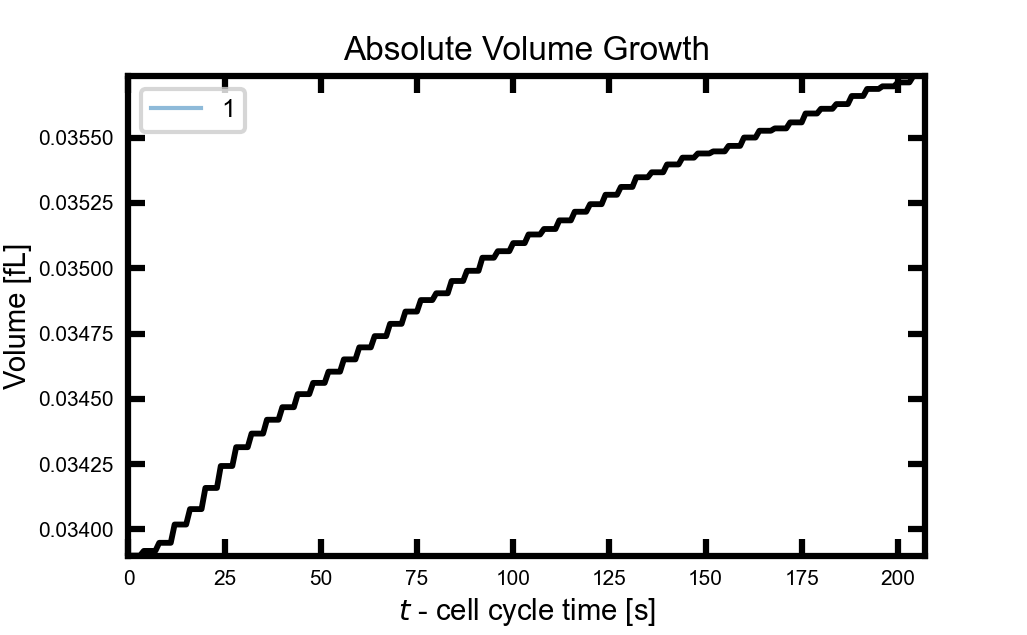

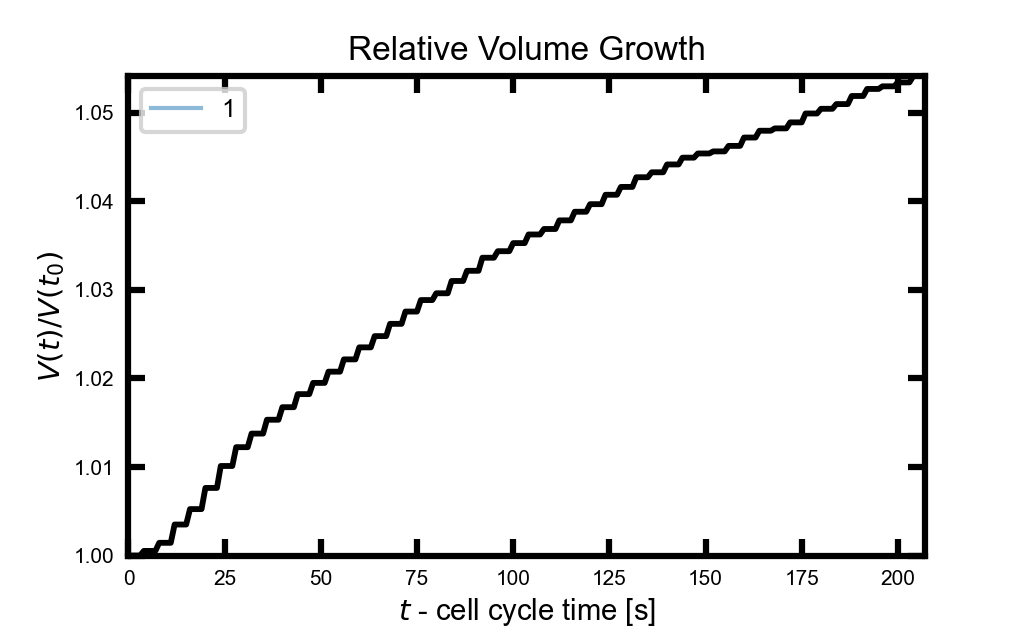

Plotting Surface Area Growth...


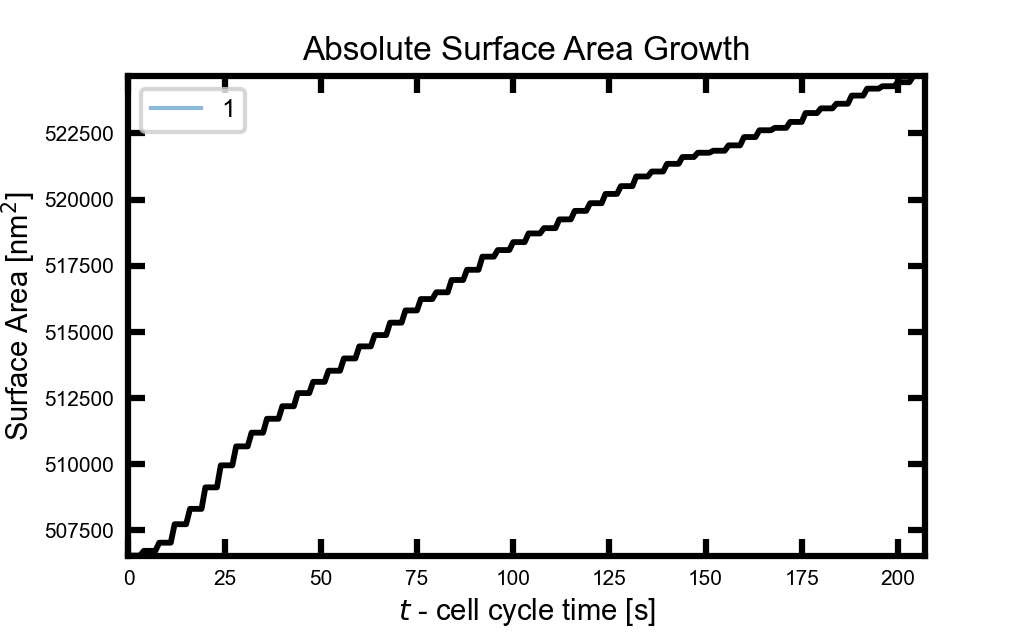

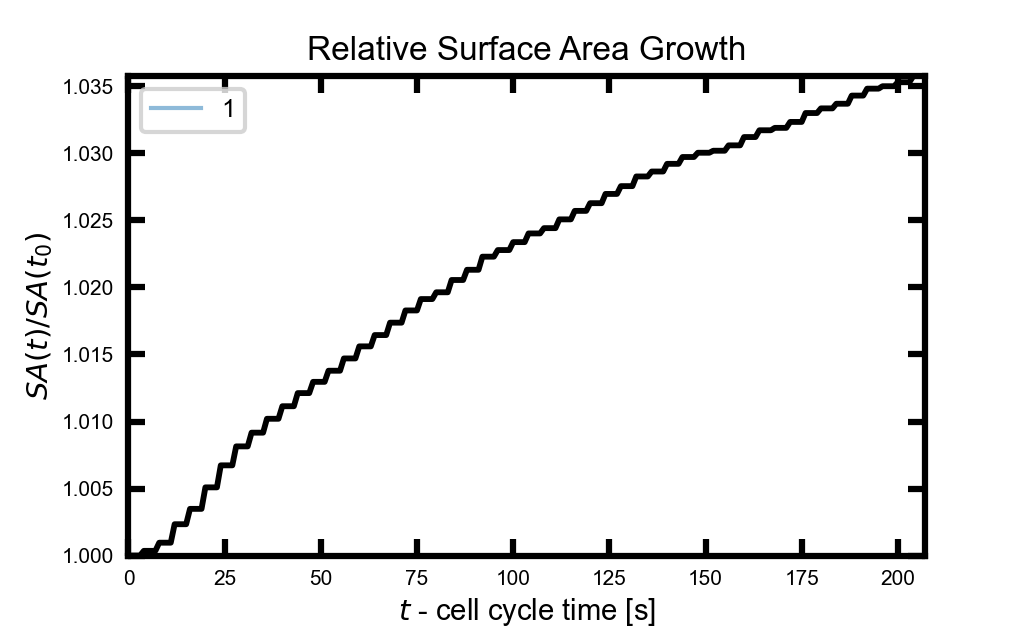

Plotting DNA Accumulation...


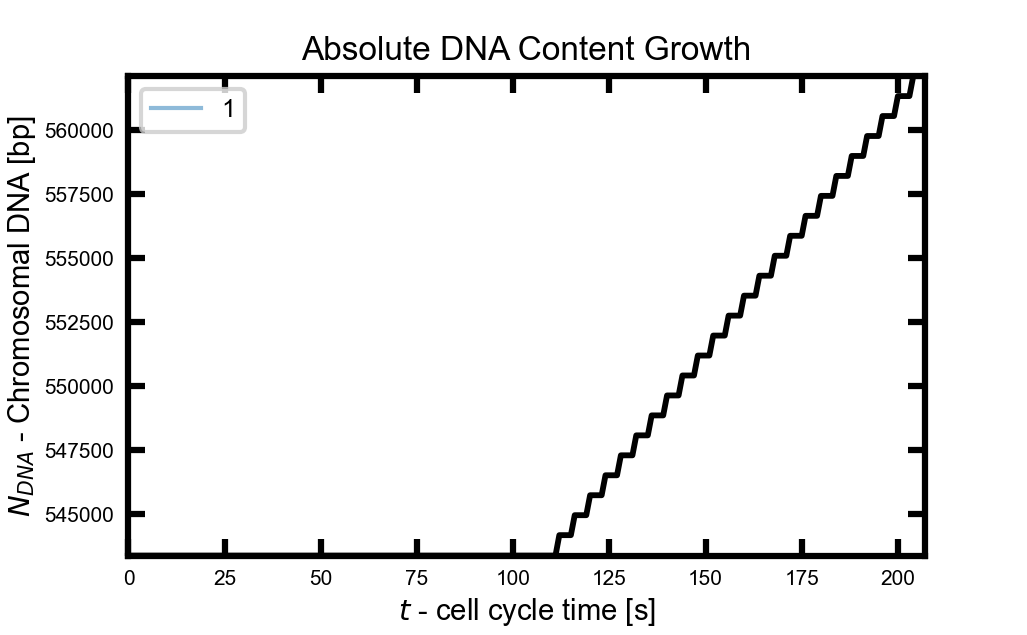

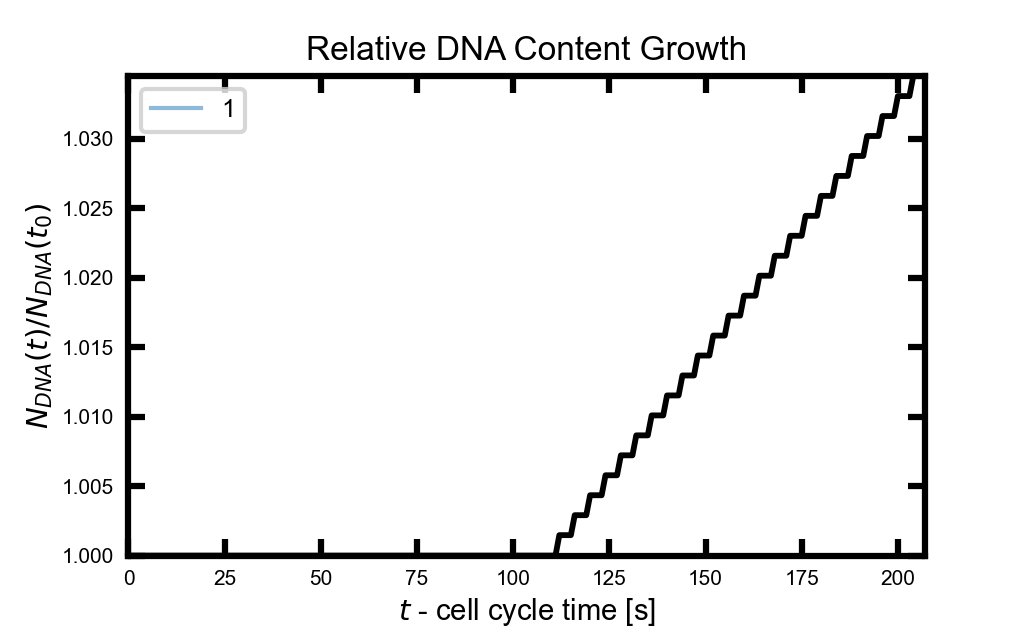

Plotting Protein Production...
(208, 1)


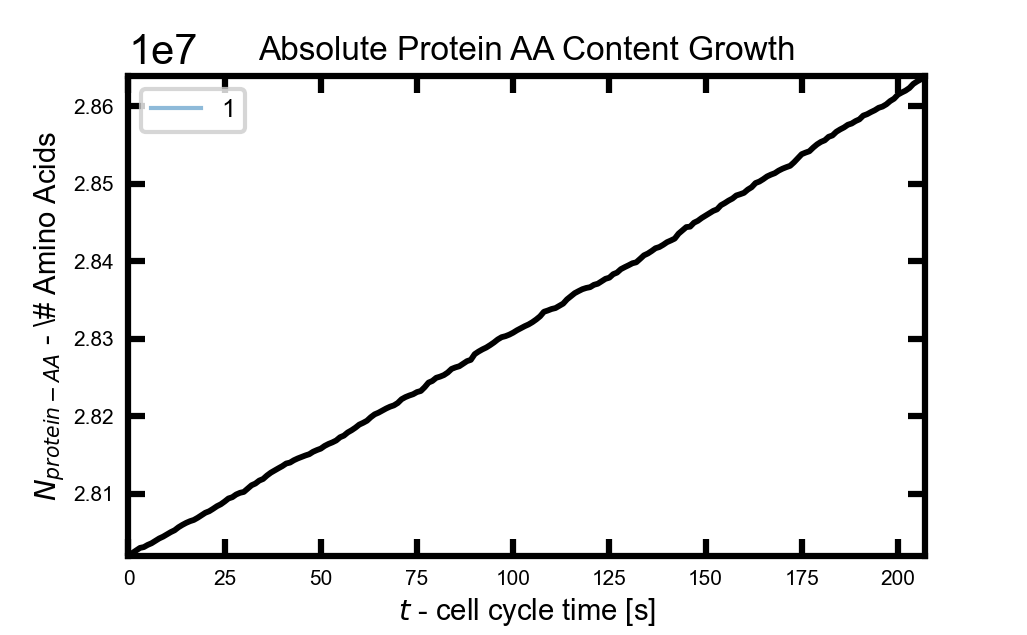

Plotting Protein and Transcript Ratios...
(208, 1)


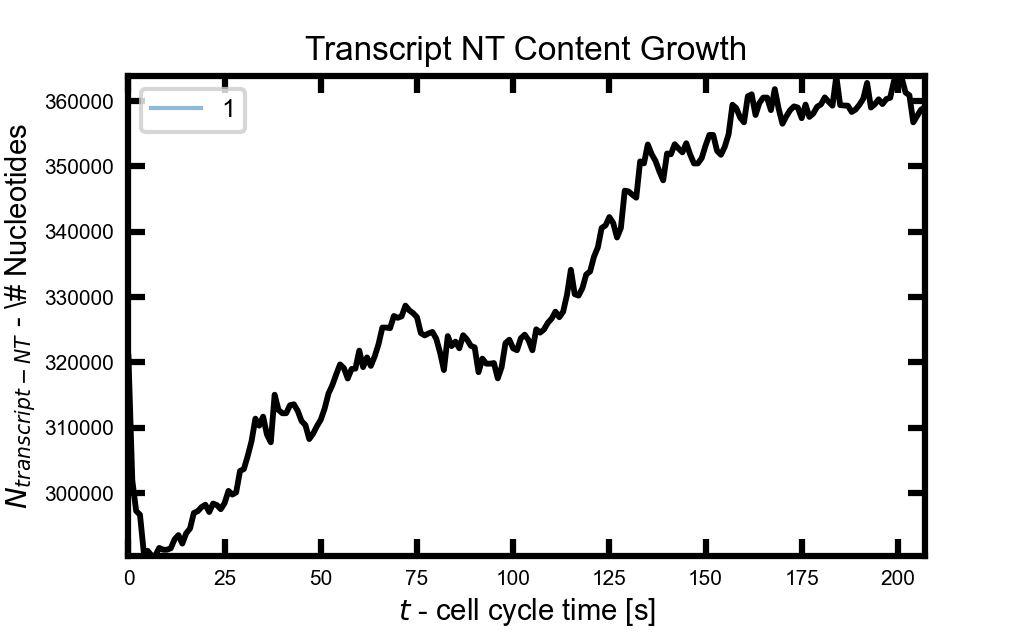

In [3]:
fig_dir = './analysis/diagnostics_fig/'
fig_label = 'replicate1'
os.makedirs(fig_dir, exist_ok=True)

# Load gene lists and lengths
w.get_filtered_locus_tags('./analysis/gene_types.txt')
lt = w.get_tagged_loci('protein')
l = w.get_loci_lengths(lt)

print("Plotting Volume Growth...")
w.plot_volume(fig_dir, fig_label, '.png', True)
display(Image(filename=os.path.join(fig_dir, f"{fig_label}_absvol.png")))
display(Image(filename=os.path.join(fig_dir, f"{fig_label}_relvol.png")))

print("Plotting Surface Area Growth...")
w.plot_surfacearea(fig_dir, fig_label, '.png', True)
display(Image(filename=os.path.join(fig_dir, f"{fig_label}_absSA.png")))
display(Image(filename=os.path.join(fig_dir, f"{fig_label}_relSA.png")))

print("Plotting DNA Accumulation...")
w.plot_DNAcontent(fig_dir, fig_label, '.png', True)
display(Image(filename=os.path.join(fig_dir, f"{fig_label}_absDNA.png")))
display(Image(filename=os.path.join(fig_dir, f"{fig_label}_relDNA.png")))

print("Plotting Protein Production...")
w.plot_protein_metrics(fig_dir, fig_label, '.png', lt, l, True)
display(Image(filename=os.path.join(fig_dir, f"{fig_label}_absProteinAAs.png")))

print("Plotting Protein and Transcript Ratios...")
w.plot_protein_transcript_metrics(fig_dir, fig_label, '.png', lt, l, True)
display(Image(filename=os.path.join(fig_dir, f"{fig_label}_absProteinTranscriptNTs.png")))

## 3. Metabolites & ATP Flux Analysis
We extract concentration profiles for key species like ATP, ADP, and AMP, and plot reaction rates for ATP-consuming and producing reactions.

Plotting concentrations for ['M_atp_c', 'M_adp_c', 'M_amp_c', 'M_pep_c', 'M_fdp_c', 'M_pi_c']...


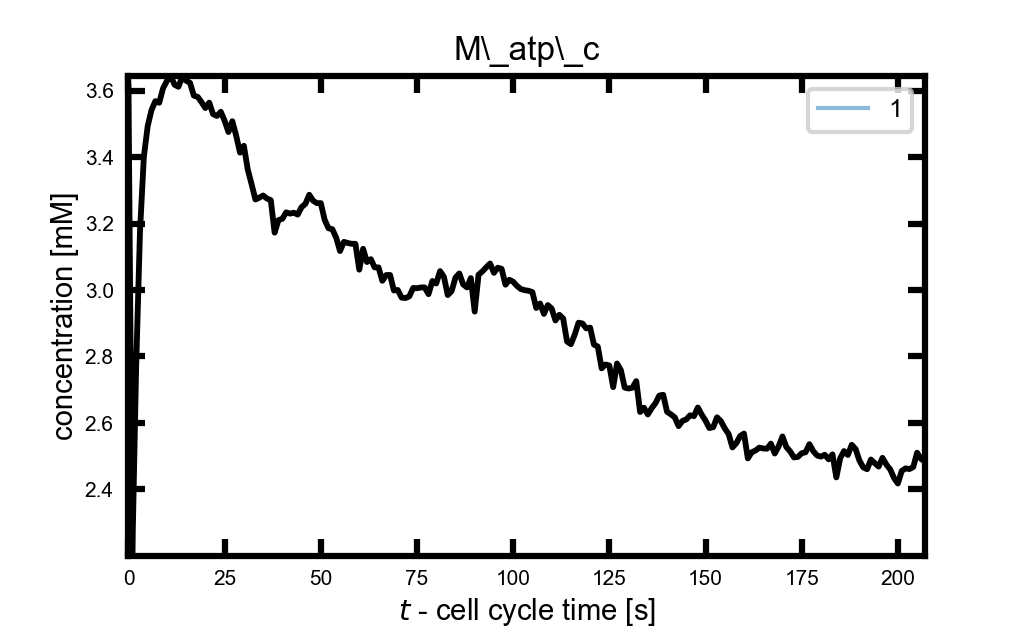

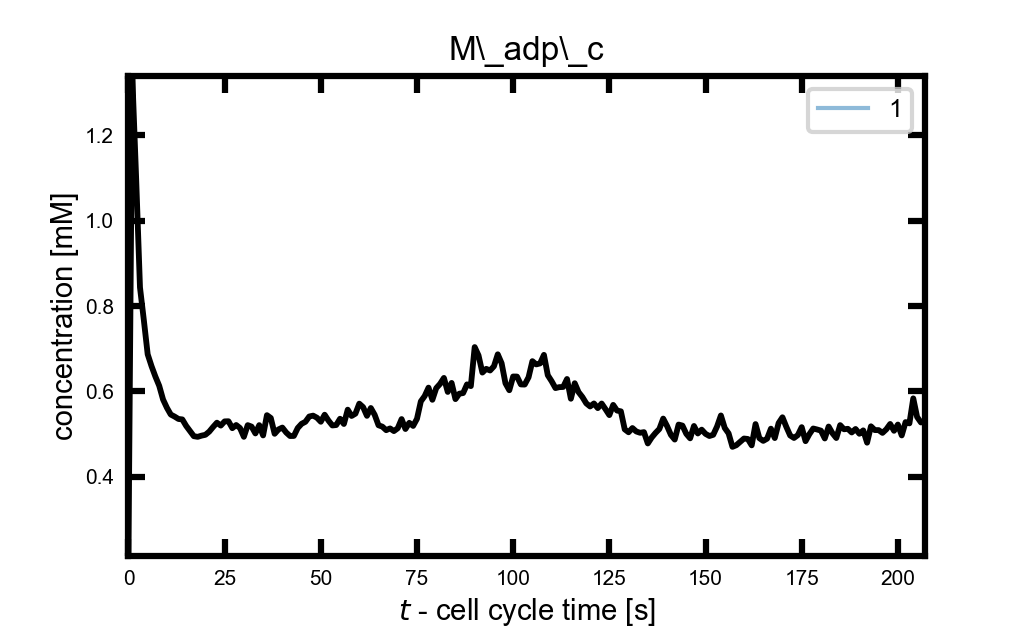

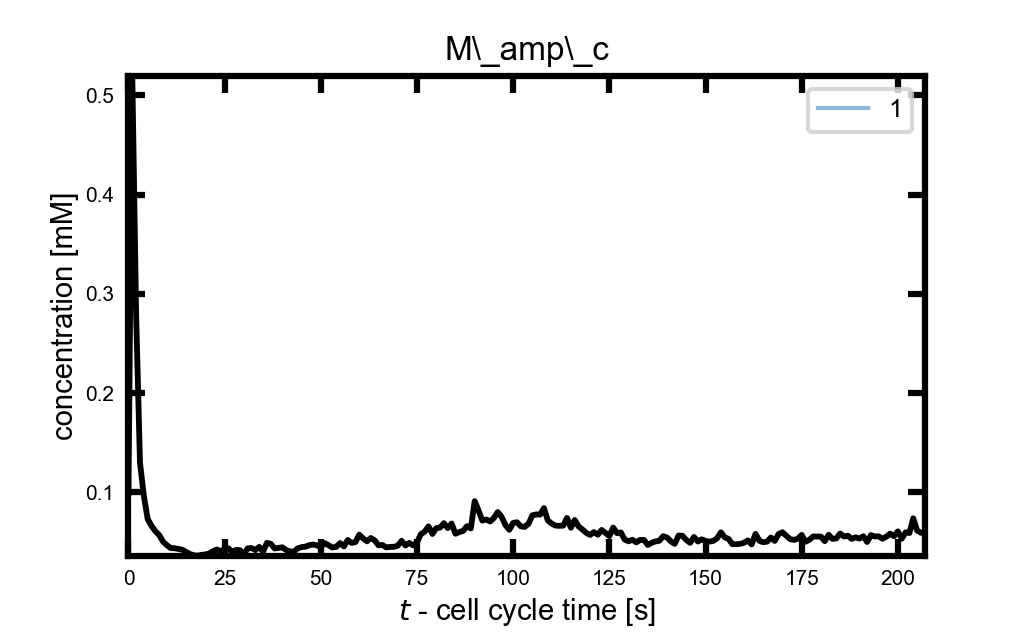

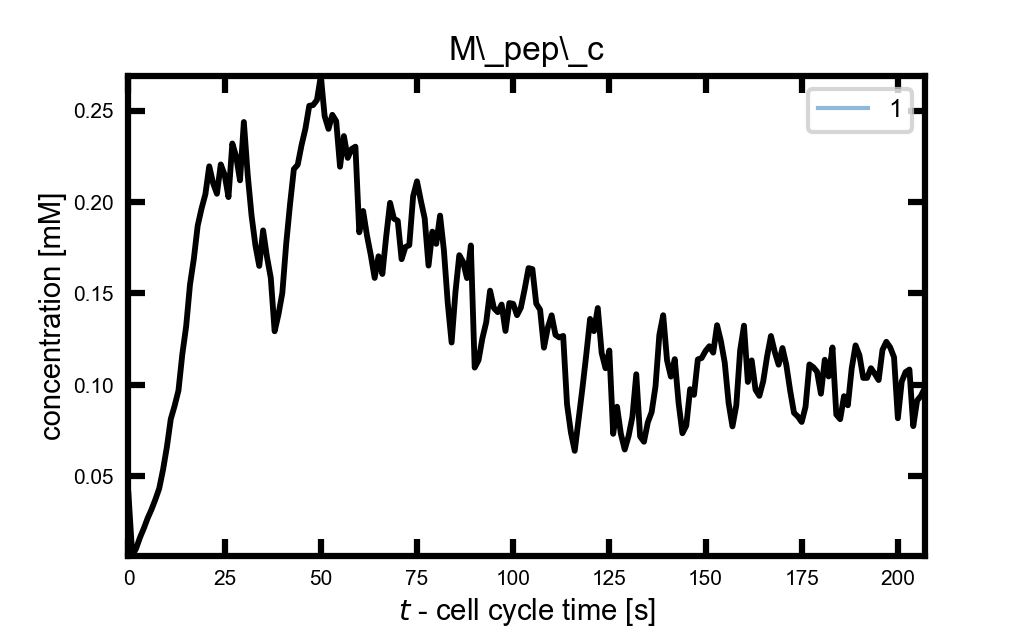

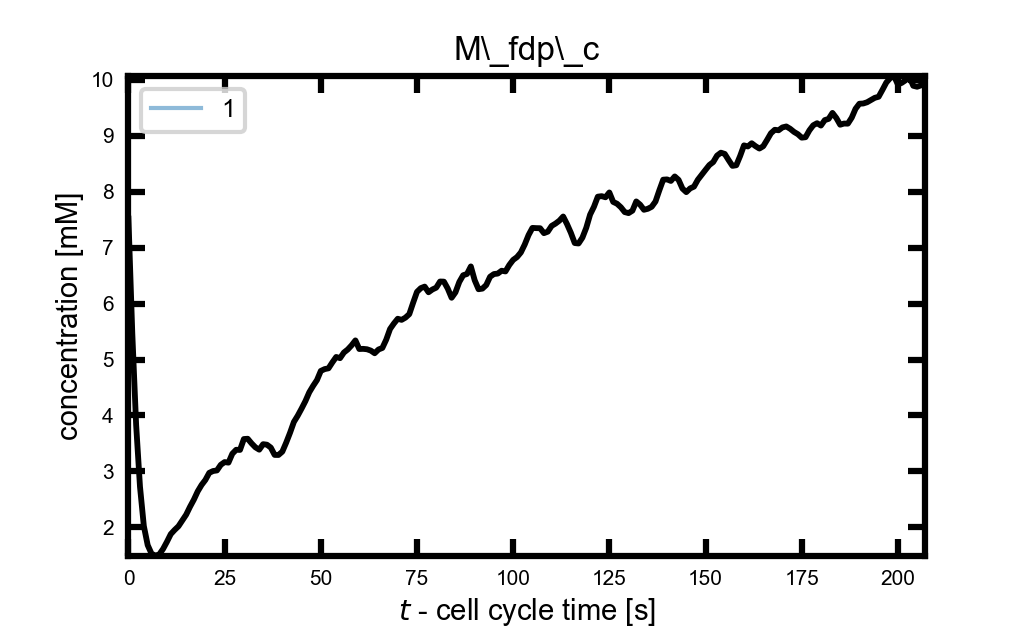

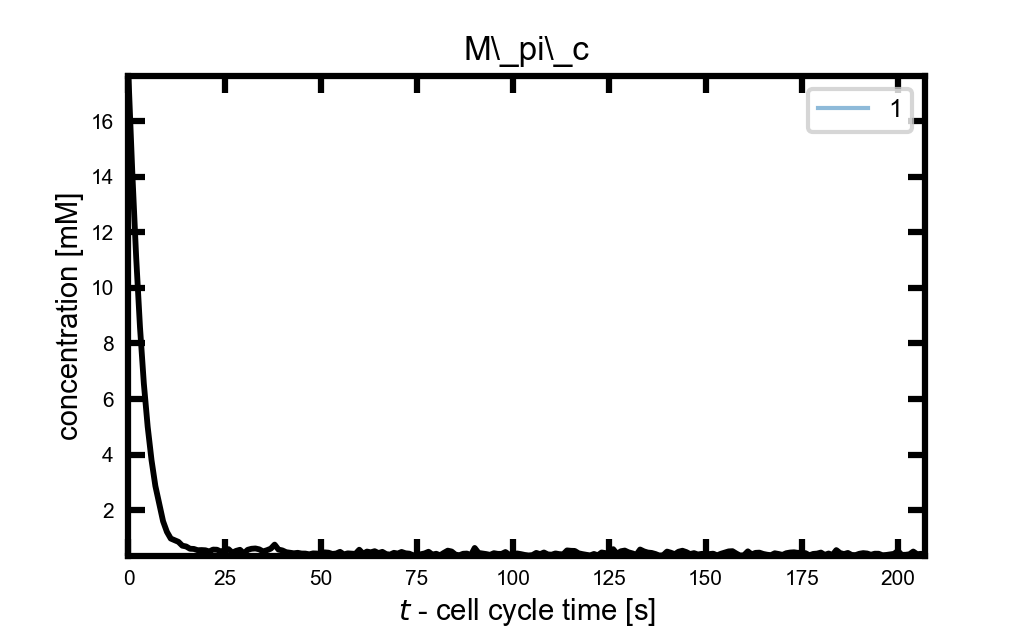

Plotting fluxes for ['PGI', 'PFK', 'GAPD', 'PYK']...


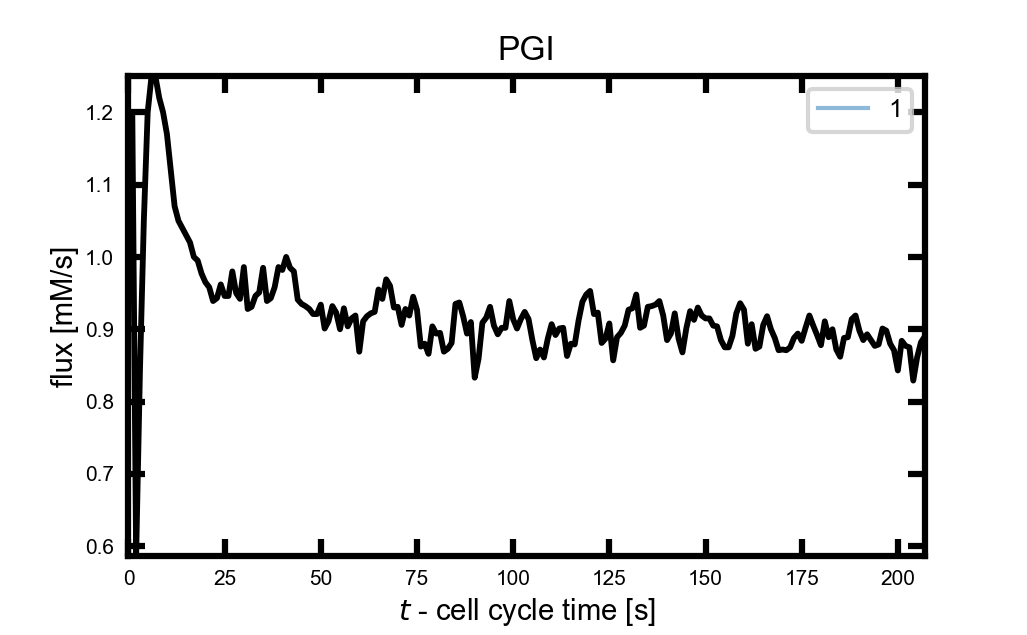

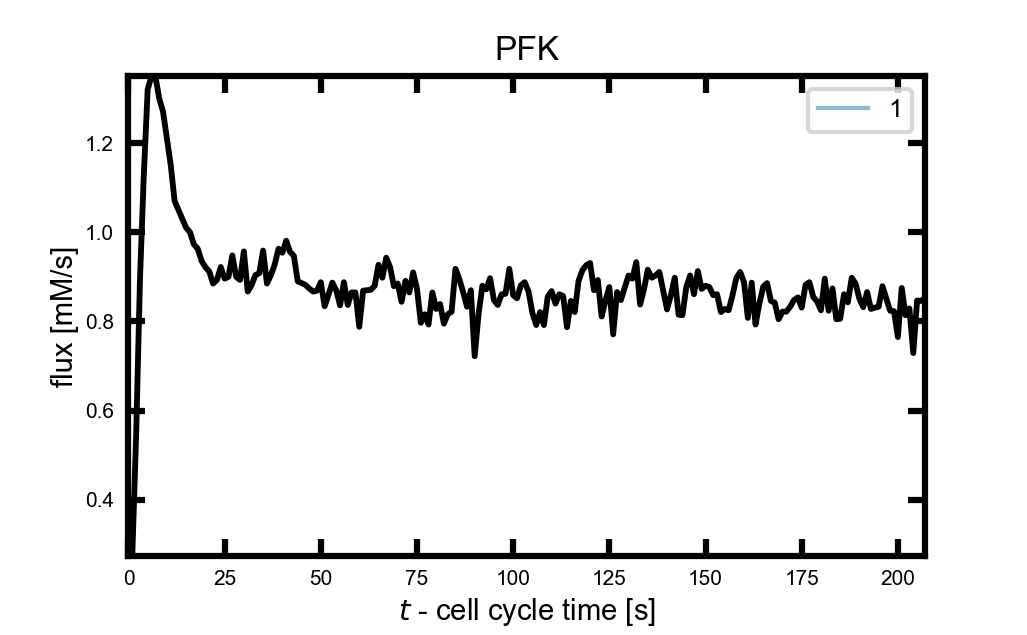

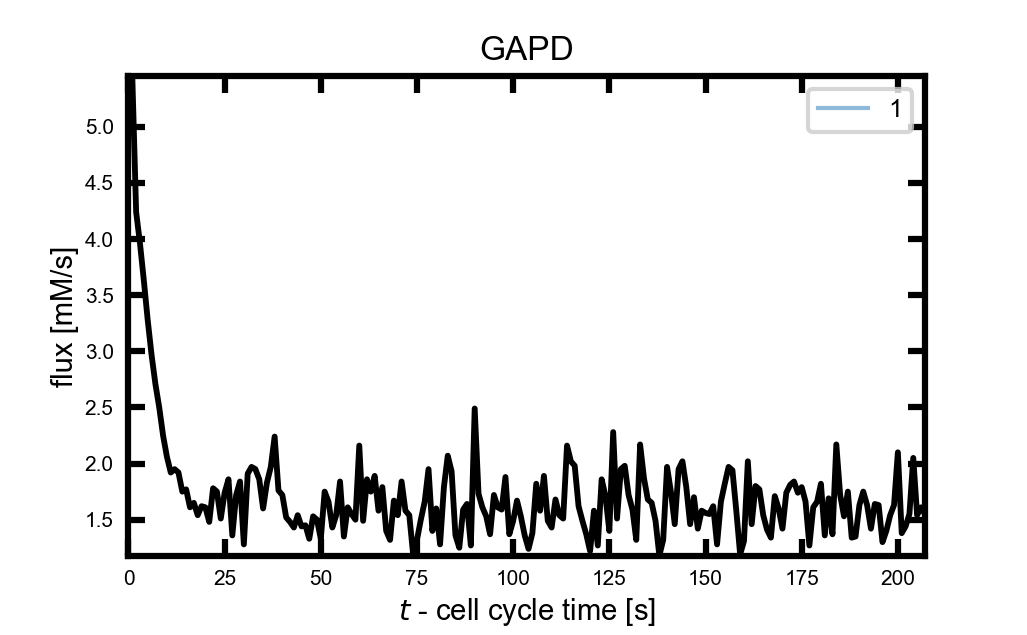

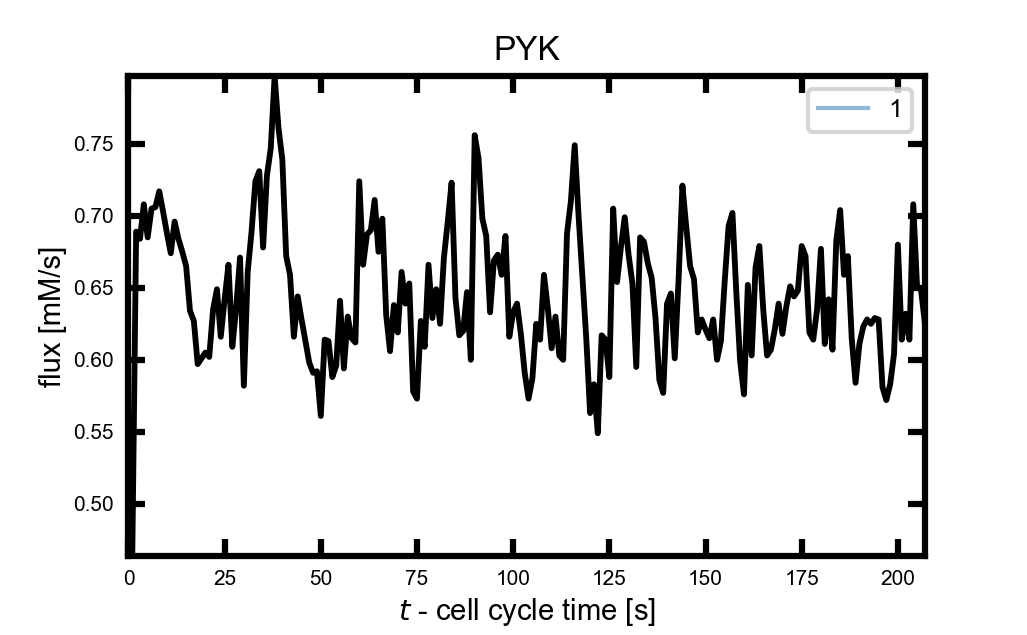

In [4]:
metabolites_to_plot = ['M_atp_c', 'M_adp_c', 'M_amp_c', 'M_pep_c', 'M_fdp_c', 'M_pi_c']
print(f"Plotting concentrations for {metabolites_to_plot}...")
w.plot_individual_concentrations(fig_dir, fig_label, '.png', metabolites_to_plot, True)
for met in metabolites_to_plot:
    display(Image(filename=os.path.join(fig_dir, f"{fig_label}_conc.{met}.png")))

atp_rxns = ['PGI', 'PFK', 'GAPD', 'PYK']
print(f"Plotting fluxes for {atp_rxns}...")
w.plot_individual_rxns(fig_dir, fig_label, '.png', atp_rxns, True)
for rxn in atp_rxns:
    display(Image(filename=os.path.join(fig_dir, f"{fig_label}_flux.{rxn}.png")))

## 4. Genetic Information Processing (GIP)
Using the JCVI-syn3A genome definitions in `syn3A.gb` and categorized gene lists, we calculate cell volume and cell surface area doubling times.

In [5]:
gbfile_path = './input_data/syn3A.gb'
gene_types_path = './analysis/gene_types.txt'

if os.path.exists(gbfile_path) and os.path.exists(gene_types_path):
    w.get_filtered_locus_tags(gene_types_path)
    genomeDict = gene.mapDNA(gbfile_path)
    TypetoLocusNums, geneTypes = gene.categorizeGenes(gbfile_path)
    
    w_gip = WCM_analysis_4DWCM.WCM_ensemble()
    w_gip.read_merged_ensemble(out_dir, out_label)
    w_gip.read_genome(gbfile_path)
    
    healthy_list = [1]
    
    vol_doubling, _ = diagnosis.get_volume_doubling_times(w_gip, healthy_list)
    surf_doubling, _ = diagnosis.get_surface_doubling_times(w_gip, healthy_list)
    
    if len(vol_doubling) > 0 and vol_doubling[0] is not None:
        print(f"Volume Doubling Time: {vol_doubling[0]:.2f} seconds")
    else:
        print("Volume did not double during the simulation period.")
        
    if len(surf_doubling) > 0 and surf_doubling[0] is not None:
        print(f"Surface Area Doubling Time: {surf_doubling[0]:.2f} seconds")
    else:
        print("Surface area did not double during the simulation period.")
else:
    print("Genome file or gene types file missing. Check `./input_data/` and `./analysis/` folders.")

Six types of genes in Syn3A are protein, ncRNA, gene, rRNA, tRNA, tmRNA with respective numbers 455, 2, 3, 6, 29, 1.
Six types of genes in Syn3A are protein, ncRNA, gene, rRNA, tRNA, tmRNA with respective numbers 455, 2, 3, 6, 29, 1.
1 replicates 1 in input 1 reps don't double the Volume
Volume Doubling Time: Minimum, Median, Mean, and Maximum is -0.02, -0.02, -0.02, -0.02 minutes
1 replicates 1 in input 1 reps don't double the Surface Area
Surface Area Doubling Time: Minimum, Median, Mean, and Maximum is -0.02, -0.02, -0.02, -0.02 minutes
Volume Doubling Time: -1.00 seconds
Surface Area Doubling Time: -1.00 seconds


## 5. Spatial & Lattice Trajectory Analysis
Using the Lattice Microbes output file `MinCell.lm`, we extract the spatial coordinates of key macromolecules and visualize their 3D/2D distributions.

In [6]:
lm_file = './Data/replicate1/MinCell.lm'

if os.path.exists(lm_file):
    traj = h5py.File(lm_file, 'r')
    
    # Print Lattice metadata
    site_names_attr = traj['Parameters'].attrs['siteTypeNames']
    if hasattr(site_names_attr, 'decode'):
        site_names = site_names_attr.decode("utf-8").split(',')
    else:
        site_names = site_names_attr.split(',')
    print("Lattice site compartments:", site_names)
    
    species_names_bin = traj['Parameters']['SpeciesNames']
    species_names = []
    for n in species_names_bin:
        val = n[0]
        if hasattr(val, 'decode'):
            val = val.decode("utf-8")
        species_names.append(val)
    print(f"Number of species on the lattice: {len(species_names)}")
    
    lattice_times = list(traj['Simulations']['0000001']['LatticeTimes'])
    print(f"Lattice timestamps (first 5): {lattice_times[:5]}")
    
    # Get spatial coordinates of active ribosomes at the final step
    final_time = int(lattice_times[-1])
    lattice_data = np.array(traj['Simulations']['0000001']['Lattice']['{:010d}'.format(final_time)])
    
    ribo_name = 'ribosome_active'
    if ribo_name in species_names:
        ribo_idx = species_names.index(ribo_name) + 1
        ribo_coords = np.argwhere(lattice_data == ribo_idx)
        print(f"Active Ribosomes on the lattice: {len(ribo_coords)}")
        
        if len(ribo_coords) > 0:
            fig, ax = plt.subplots(figsize=(6, 6))
            ax.hist2d(ribo_coords[:, 1], ribo_coords[:, 2], bins=32, cmap='Oranges')
            ax.set_aspect('equal')
            ax.set_title("Ribosome Spatial Distribution Projection (Y-Z plane)")
            ax.set_xlabel("Y position")
            ax.set_ylabel("Z position")
            plt.show()
else:
    print(f"MinCell.lm not found at {lm_file}.")

Lattice site compartments: ['extracellular', 'cytoplasm', 'outer_cytoplasm', 'ribosomes', 'ribo_centers', 'DNA', 'membrane']
Number of species on the lattice: 5489
Lattice timestamps (first 5): [0.0, 1.0, 2.0, 3.0, 4.0]


## 6. Simulation Timing & Performance
If you redirected simulation stdout to a log file (e.g. `./Whole_Cell_Minimal_Cell.log`), we parse it and analyze execution runtimes of each simulation solver.

In [7]:
run_log_path = './Whole_Cell_Minimal_Cell.log'

if os.path.exists(run_log_path):
    with open(run_log_path, 'r') as file:
        logLines = [line.rstrip() for line in file]
        
    RDME_times = []
    Ribo_times = []
    CME_times = []
    ODE_times = []
    DNA_times = []
    Write_times = []

    for line in logLines:
        if line.startswith('Non-Hook RDME Time'):
            RDME_times.append(float(line.split(':')[1]))
        elif line.startswith('Ribo time'):
            Ribo_times.append(float(line.split(':')[1]))
        elif line.startswith('CME time'):
            CME_times.append(float(line.split(':')[1]))
        elif line.startswith('ODE time'):
            ODE_times.append(float(line.split(':')[1]))
        elif line.startswith('DNA time'):
            DNA_times.append(float(line.split(':')[1]))
        elif line.startswith('Communication and file write time'):
            Write_times.append(float(line.split(':')[1]))

    if len(RDME_times) > 0:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(RDME_times, label='RDME')
        ax.plot(Ribo_times, label='Ribosome')
        ax.plot(CME_times, label='CME')
        ax.plot(ODE_times, label='ODE')
        ax.plot(DNA_times, label='BD-DNA')
        ax.plot(Write_times, label='File Write')
        ax.set_ylabel('Time (seconds)')
        ax.set_xlabel('Steps')
        ax.set_title('Execution Timing Analysis')
        ax.legend()
        plt.show()
    else:
        print("Timing data found in log was empty or not formatted correctly.")
else:
    print(f"No stdout run log file found at {run_log_path}.")
    print("To enable this plot, run your simulation by redirecting stdout to a file:")
    print("  python Whole_Cell_Minimal_Cell.py -od replicate1 -t 1200 -cd 0 -drs 13 -dsd ./software/ > Whole_Cell_Minimal_Cell.log")

No stdout run log file found at ./Whole_Cell_Minimal_Cell.log.
To enable this plot, run your simulation by redirecting stdout to a file:
  python Whole_Cell_Minimal_Cell.py -od replicate1 -t 1200 -cd 0 -drs 13 -dsd ./software/ > Whole_Cell_Minimal_Cell.log
